In [21]:
import data_loader
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from skimage import color
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import f1_score, roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report
from joblib import Parallel, delayed
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.utils import resample
from collections import defaultdict

In [22]:
train, val, test = data_loader.load_masks()

In [23]:
def sliding_window(image, step_size, window_size):
    for y in range(0, image.shape[0], step_size):
        for x in range(0, image.shape[1], step_size):
            yield (x, y, image[y:y+window_size[1], x:x+window_size[0]])

In [24]:
def extract_features(window):
    """Optimized feature extraction."""
    if window.size == 0:
        return np.zeros(114)
    
    h, w = window.shape[:2]
    area = h * w
    window_float = window.astype(np.float32) / 255.0
    
    features = []
    
    # RGB histograms and stats (batch process)
    for channel in range(3):
        channel_data = window[:, :, channel] / 255.0
        hist = np.histogram(channel_data, bins=16, range=(0, 1))[0]
        features.extend(hist / area)
        features.append(np.mean(channel_data))
        features.append(np.std(channel_data))
    
    # HSV histograms
    hsv = color.rgb2hsv(window_float)
    for channel in range(3):
        hist = np.histogram(hsv[:, :, channel], bins=16, range=(0, 1))[0]
        features.extend(hist / area)
    
    # LBP (use uint8 to avoid warning and improve speed)
    gray = color.rgb2gray(window_float)
    gray_uint8 = (gray * 255).astype(np.uint8)
    lbp = local_binary_pattern(gray_uint8, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
    features.extend(lbp_hist / lbp.size)
    
    # Gradients (reuse gray_uint8)
    grad_x = cv2.Sobel(gray_uint8, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray_uint8, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    features.extend([np.mean(grad_mag), np.std(grad_mag)])
    
    return np.array(features)

def process_window(args):
    """Process a single window for parallel execution."""
    x, y, window_patch, mask_patch = args
    feature_vector = extract_features(window_patch)
    # Multi-class: use majority category in patch (0=background, 1-6=damage types)
    unique, counts = np.unique(mask_patch, return_counts=True)
    if len(unique) > 0:
        # Get the most common category (excluding 0 if there are damage pixels)
        damage_pixels = mask_patch[mask_patch > 0]
        if len(damage_pixels) > (mask_patch.size * 0.1):  # 10% threshold
            label = int(np.bincount(damage_pixels).argmax())  # Most common damage category
        else:
            label = 0  # Background
    else:
        label = 0  # Background
    return feature_vector, label

In [25]:
# Parallel feature extraction
n_jobs = 8
print(f"Using {n_jobs} CPU cores for parallel processing...")
start_time = time.time()

# Collect all windows and mask patches first
all_windows_data = []
print("Collecting windows from training images...")
for data in tqdm(train, desc="Collecting windows"):
    image = data['image']
    mask = data['mask']
    
    windows = list(sliding_window(image, 128, (128, 128)))
    for x, y, window_patch in windows:
        h, w = window_patch.shape[:2]
        mask_patch = mask[y:y+h, x:x+w]
        all_windows_data.append((x, y, window_patch, mask_patch))

print(f"Total windows collected: {len(all_windows_data)}")

# Extract labels first to balance classes (multi-class)
print("Pre-labeling windows for balanced sampling...")
pre_labels = []
for data in tqdm(all_windows_data, desc="Pre-labeling"):
    x, y, window_patch, mask_patch = data
    # Multi-class label extraction
    damage_pixels = mask_patch[mask_patch > 0]
    if len(damage_pixels) > (mask_patch.size * 0.1):  # 10% threshold
        label = int(np.bincount(damage_pixels).argmax())  # Most common damage category
    else:
        label = 0  # Background
    pre_labels.append(label)

# Separate by class (0=background, 1-6=damage types)
class_windows = defaultdict(list)
for w, l in zip(all_windows_data, pre_labels):
    class_windows[l].append(w)

print("Class distribution:")
for class_id in sorted(class_windows.keys()):
    print(f"  Class {class_id}: {len(class_windows[class_id])} windows")

# Sample 10% from each class, then balance
min_class_size = min(len(windows) for windows in class_windows.values())
sample_size = int(min_class_size * 0.1)  # 10% of the smallest class

print(f"Sampling {sample_size} windows from each class (balanced)...")

# Sample from each class
sampled_windows = []
for class_id in sorted(class_windows.keys()):
    class_data = class_windows[class_id]
    if len(class_data) >= sample_size:
        sampled = resample(class_data, n_samples=sample_size, random_state=42, replace=False)
        sampled_windows.extend(sampled)
        print(f"  Class {class_id}: sampled {len(sampled)} windows")

# Combine and shuffle
all_windows_data = sampled_windows
np.random.seed(42)
np.random.shuffle(all_windows_data)

print(f"Final balanced dataset: {len(all_windows_data)} windows ({len(class_windows)} classes)")

# Process in parallel with joblib (better progress bar support)
print(f"Processing {len(all_windows_data)} windows with {n_jobs} workers...")

# Use joblib with verbose output - it shows progress automatically
results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(process_window)(data) for data in tqdm(all_windows_data, desc="Extracting features")
)

# Unpack results
all_features, all_labels = zip(*results)
X = np.array(all_features)
y = np.array(all_labels)

elapsed = time.time() - start_time
print(f"Extracted {len(X)} feature vectors in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"Feature vector dimension: {X.shape[1]}")
print(f"Class distribution: {np.bincount(y)}")

Using 8 CPU cores for parallel processing...


Total windows collected: 134824
Pre-labeling windows for balanced sampling...


Pre-labeling: 100%|██████████| 134824/134824 [00:21<00:00, 6261.67it/s] 


Class distribution:
  Class 0: 88372 windows
  Class 1: 10970 windows
  Class 2: 12538 windows
  Class 3: 429 windows
  Class 4: 13404 windows
  Class 5: 5261 windows
  Class 6: 3850 windows
Sampling 42 windows from each class (balanced)...
  Class 0: sampled 42 windows
  Class 1: sampled 42 windows
  Class 2: sampled 42 windows
  Class 3: sampled 42 windows
  Class 4: sampled 42 windows
  Class 5: sampled 42 windows
  Class 6: sampled 42 windows
Final balanced dataset: 294 windows (7 classes)
Processing 294 windows with 8 workers...


Extracting features:   5%|▌         | 16/294 [00:03<01:01,  4.51it/s][Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    3.1s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    3.2s
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    3.2s
Extracting features:  11%|█         | 32/294 [00:03<00:23, 11.34it/s][Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    3.3s
[Parallel(n_jobs=8)]: Batch computation too fast (0.19705520217601766s.) Setting batch_size=2.
Extracting features:  16%|█▋        | 48/294 [00:03<00:12, 20.15it/s][Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    3.4s
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:    3.4s
[Parallel(n_jobs=8)]: Batch computation too fast (0.09787702560424805s.) Setting batch_size=4.
Extracting features:  27%|██▋       | 80/294 [00:03<00:04, 43.50it/s][Parallel(n_jobs=8)]: Done  64 tasks      | elapsed:    3.5s
[Parallel(n_jobs=8)]: Batch computation too fast (0.1638801097869873s.) Setting batch_size=8.
Extracting fe

Extracted 294 feature vectors in 61.2 seconds (1.0 minutes)
Feature vector dimension: 114
Class distribution: [42 42 42 42 42 42 42]


In [26]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [27]:
def run_svm():
    # Multi-class SVM (one-vs-rest by default)
    clf = svm.SVC(decision_function_shape='ovr')  # Explicitly set one-vs-rest
    print("Training multi-class SVM...")
    clf.fit(scaled_X, y)
    print("Training complete!")
    return clf

In [28]:
clf = run_svm()

# Parallel feature extraction for test set
print("Extracting test features...")
start_time = time.time()

test_windows_data = []
print("Collecting windows from test images...")
for data in tqdm(test, desc="Collecting test windows"):
    image = data['image']
    mask = data['mask']
    
    windows = list(sliding_window(image, 128, (128, 128)))
    for x, y, window_patch in windows:
        h, w = window_patch.shape[:2]
        mask_patch = mask[y:y+h, x:x+w]
        test_windows_data.append((x, y, window_patch, mask_patch))

print(f"Total test windows collected: {len(test_windows_data)}")

# Extract labels first to balance test classes (multi-class)
print("Pre-labeling test windows for balanced sampling...")
test_pre_labels = []
for data in tqdm(test_windows_data, desc="Pre-labeling test"):
    x, y, window_patch, mask_patch = data
    # Multi-class label extraction
    damage_pixels = mask_patch[mask_patch > 0]
    if len(damage_pixels) > (mask_patch.size * 0.1):  # 10% threshold
        label = int(np.bincount(damage_pixels).argmax())  # Most common damage category
    else:
        label = 0  # Background
    test_pre_labels.append(label)

# Separate by class (multi-class)
test_class_windows = defaultdict(list)
for w, l in zip(test_windows_data, test_pre_labels):
    test_class_windows[l].append(w)

print("Test class distribution:")
for class_id in sorted(test_class_windows.keys()):
    print(f"  Class {class_id}: {len(test_class_windows[class_id])} windows")

# Sample 10% from each class, then balance
test_min_class_size = min(len(windows) for windows in test_class_windows.values())
test_sample_size = int(test_min_class_size * 0.1)  # 10% of the smallest class

print(f"Sampling {test_sample_size} windows from each test class (balanced)...")

# Sample from each class
test_sampled_windows = []
for class_id in sorted(test_class_windows.keys()):
    class_data = test_class_windows[class_id]
    if len(class_data) >= test_sample_size:
        sampled = resample(class_data, n_samples=test_sample_size, random_state=42, replace=False)
        test_sampled_windows.extend(sampled)
        print(f"  Class {class_id}: sampled {len(sampled)} windows")

# Combine and shuffle
test_windows_data = test_sampled_windows
np.random.seed(42)
np.random.shuffle(test_windows_data)

print(f"Final balanced test dataset: {len(test_windows_data)} windows ({len(test_class_windows)} classes)")

# Process in parallel with joblib
print(f"Processing {len(test_windows_data)} test windows...")
test_results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(process_window)(data) for data in tqdm(test_windows_data, desc="Extracting test features")
)

test_features, test_labels = zip(*test_results)
X_test = np.array(test_features)
y_test = np.array(test_labels)

scaled_X_test = scaler.transform(X_test)

elapsed = time.time() - start_time
print(f"Test features extracted in {elapsed:.1f} seconds")

Training multi-class SVM...
Training complete!
Extracting test features...


Total test windows collected: 17880
Pre-labeling test windows for balanced sampling...


Pre-labeling test: 100%|██████████| 17880/17880 [00:00<00:00, 18612.85it/s]


Test class distribution:
  Class 0: 11683 windows
  Class 1: 1463 windows
  Class 2: 1525 windows
  Class 3: 60 windows
  Class 4: 2021 windows
  Class 5: 637 windows
  Class 6: 491 windows
Sampling 6 windows from each test class (balanced)...
  Class 0: sampled 6 windows
  Class 1: sampled 6 windows
  Class 2: sampled 6 windows
  Class 3: sampled 6 windows
  Class 4: sampled 6 windows
  Class 5: sampled 6 windows
  Class 6: sampled 6 windows
Final balanced test dataset: 42 windows (7 classes)
Processing 42 test windows...


Extracting test features:   0%|          | 0/42 [00:00<?, ?it/s][Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Batch computation too fast (0.06676411628723145s.) Setting batch_size=2.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:    0.1s
Extracting test features: 100%|██████████| 42/42 [00:00<00:00, 242.63it/s]
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Batch computation too fast (0.103271484375s.) Setting batch_size=4.


Test features extracted in 2.9 seconds


[Parallel(n_jobs=8)]: Done  32 out of  42 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  37 out of  42 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  42 out of  42 | elapsed:    0.1s finished


In [29]:
# Get predictions and decision scores for evaluation
predictions = clf.predict(scaled_X_test)
decision_scores = clf.decision_function(scaled_X_test) 
accuracy = np.mean(predictions == y_test)
print(f"Test accuracy: {accuracy:.4f}")
print(f"Predictions shape: {predictions.shape}")

Test accuracy: 0.3571
Predictions shape: (42,)


EVALUATION METRICS

F1 Score (macro): 0.3377
F1 Score (weighted): 0.3377

Classification Report:
               precision    recall  f1-score   support

      Class_0       0.29      0.33      0.31         6
         dent       0.38      0.50      0.43         6
      scratch       0.40      0.33      0.36         6
        crack       0.33      0.17      0.22         6
glass shatter       0.67      0.67      0.67         6
  lamp broken       0.00      0.00      0.00         6
    tire flat       0.30      0.50      0.38         6

     accuracy                           0.36        42
    macro avg       0.34      0.36      0.34        42
 weighted avg       0.34      0.36      0.34        42


Confusion Matrix:
[[2 1 1 0 1 1 0]
 [2 3 1 0 0 0 0]
 [1 0 2 2 0 0 1]
 [0 1 0 1 1 1 2]
 [1 1 0 0 4 0 0]
 [1 1 0 0 0 0 4]
 [0 1 1 0 0 1 3]]


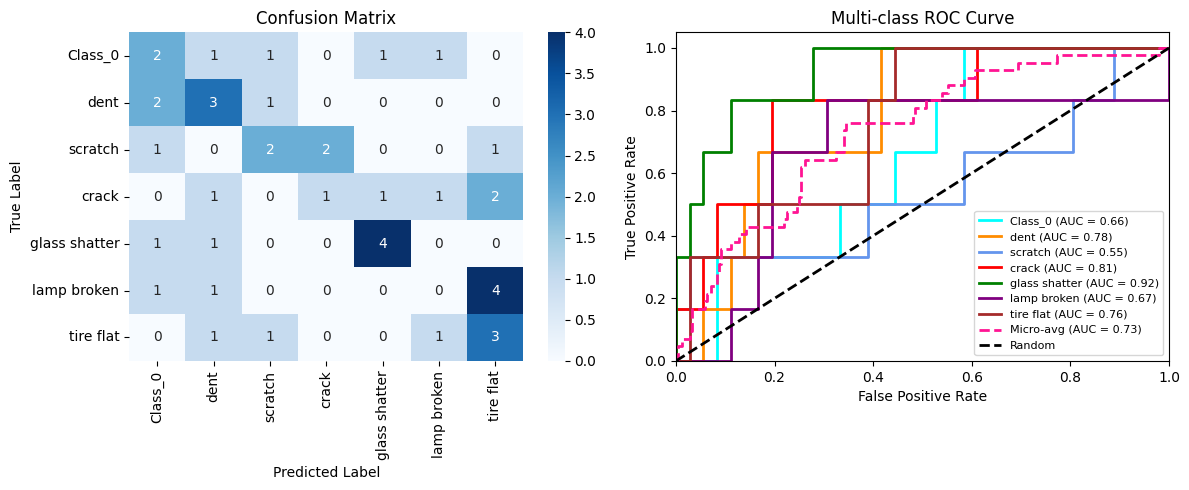


Micro-averaged ROC AUC: 0.7317
  Class_0: 0.6574
  dent: 0.7824
  scratch: 0.5509
  crack: 0.8102
  glass shatter: 0.9213
  lamp broken: 0.6713
  tire flat: 0.7593


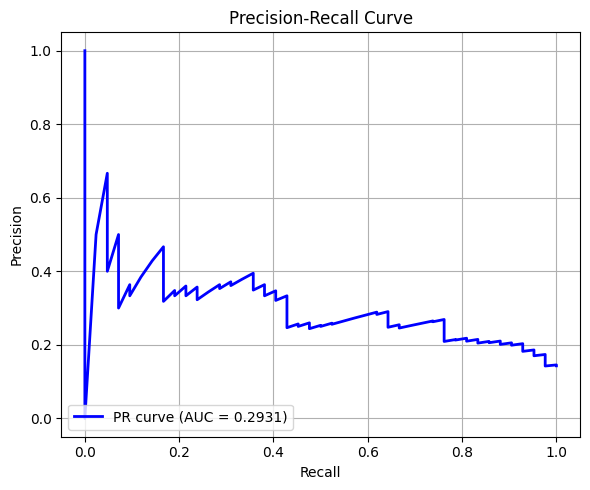

PR AUC: 0.2931


In [30]:
# Comprehensive evaluation metrics
print("=" * 60)
print("EVALUATION METRICS")
print("=" * 60)

# F1 Score (multi-class: weighted average)
f1_macro = f1_score(y_test, predictions, average='macro')
f1_weighted = f1_score(y_test, predictions, average='weighted')
print(f"\nF1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Get category names
category_map = data_loader.get_categories(data_loader.train_coco)
class_names = [category_map.get(i, f'Class_{i}') for i in sorted(np.unique(np.concatenate([y_test, predictions])))]

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions, labels=sorted(np.unique(np.concatenate([y_test, predictions]))))
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Multi-class ROC (one-vs-rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize labels for multi-class ROC
classes = sorted(np.unique(np.concatenate([y_test, predictions])))
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# Get decision scores for all classes (one-vs-rest)
if hasattr(clf, 'decision_function'):
    decision_scores_bin = clf.decision_function(scaled_X_test)
    if decision_scores_bin.ndim == 1:  # Binary case
        decision_scores_bin = np.column_stack([-decision_scores_bin, decision_scores_bin])
else:
    # Use predict_proba if available
    decision_scores_bin = clf.predict_proba(scaled_X_test)

# Compute ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], decision_scores_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), decision_scores_bin.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.subplot(1, 2, 2)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='--', lw=2,
         label=f'Micro-avg (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nMicro-averaged ROC AUC: {roc_auc['micro']:.4f}")
for i, name in enumerate(class_names):
    print(f"  {name}: {roc_auc[i]:.4f}")

# Precision-Recall Curve (micro-averaged)
precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), decision_scores_bin.ravel())
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PR AUC: {pr_auc:.4f}")
print("=" * 60)
